# 基于 wage1 数据集的薪资决定因素实证分析

**项目目标**：通过构建 Mincer 薪资方程，分析教育、工作经验、性别和婚姻状态对个人时薪（wage）的影响程度和模式。

**执行步骤**：数据探索 → Level-Level vs Semi-Log 对比 → 稳健推断与虚拟变量 → RESET 检验 → 非线性（经验平方项）→ 最终模型对比与可视化。

## 1. 环境与库

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# 加载主题包（与实战项目房价影响因素的对数模型分析一致）
from jupyterthemes import jtplot
jtplot.style(theme='oceans16')

pd.set_option('display.max_columns', 20)
%matplotlib inline

## 2. 数据初始化与探索

In [124]:
import wooldridge

In [125]:
df = wooldridge.data('wage1', description=True)

name of dataset: wage1
no of variables: 24
no of observations: 526

+----------+---------------------------------+
| variable | label                           |
+----------+---------------------------------+
| wage     | average hourly earnings         |
| educ     | years of education              |
| exper    | years potential experience      |
| tenure   | years with current employer     |
| nonwhite | =1 if nonwhite                  |
| female   | =1 if female                    |
| married  | =1 if married                   |
| numdep   | number of dependents            |
| smsa     | =1 if live in SMSA              |
| northcen | =1 if live in north central U.S |
| south    | =1 if live in southern region   |
| west     | =1 if live in western region    |
| construc | =1 if work in construc. indus.  |
| ndurman  | =1 if in nondur. manuf. indus.  |
| trcommpu | =1 if in trans, commun, pub ut  |
| trade    | =1 if in wholesale or retail    |
| services | =1 if in services indus.  

In [126]:
# 加载 wage1 数据用于后续分析（与参考 notebook 一致：上一格用 description=True 查看变量说明）
data = wooldridge.data('wage1')

In [127]:
# 核心变量：wage 时薪, educ 教育年限, exper 工作经验, tenure 现职任期, female 性别, married 婚姻
vars_core = ['wage', 'educ', 'exper', 'tenure', 'female', 'married']
print('基本统计与缺失')
print(data[vars_core].describe().round(4))
print('\n缺失值:', data[vars_core].isna().sum().to_dict())

基本统计与缺失
           wage      educ     exper    tenure    female   married
count  526.0000  526.0000  526.0000  526.0000  526.0000  526.0000
mean     5.8961   12.5627   17.0171    5.1046    0.4791    0.6084
std      3.6931    2.7690   13.5722    7.2245    0.5000    0.4886
min      0.5300    0.0000    1.0000    0.0000    0.0000    0.0000
25%      3.3300   12.0000    5.0000    0.0000    0.0000    0.0000
50%      4.6500   12.0000   13.5000    2.0000    0.0000    1.0000
75%      6.8800   14.0000   26.0000    7.0000    1.0000    1.0000
max     24.9800   18.0000   51.0000   44.0000    1.0000    1.0000

缺失值: {'wage': 0, 'educ': 0, 'exper': 0, 'tenure': 0, 'female': 0, 'married': 0}


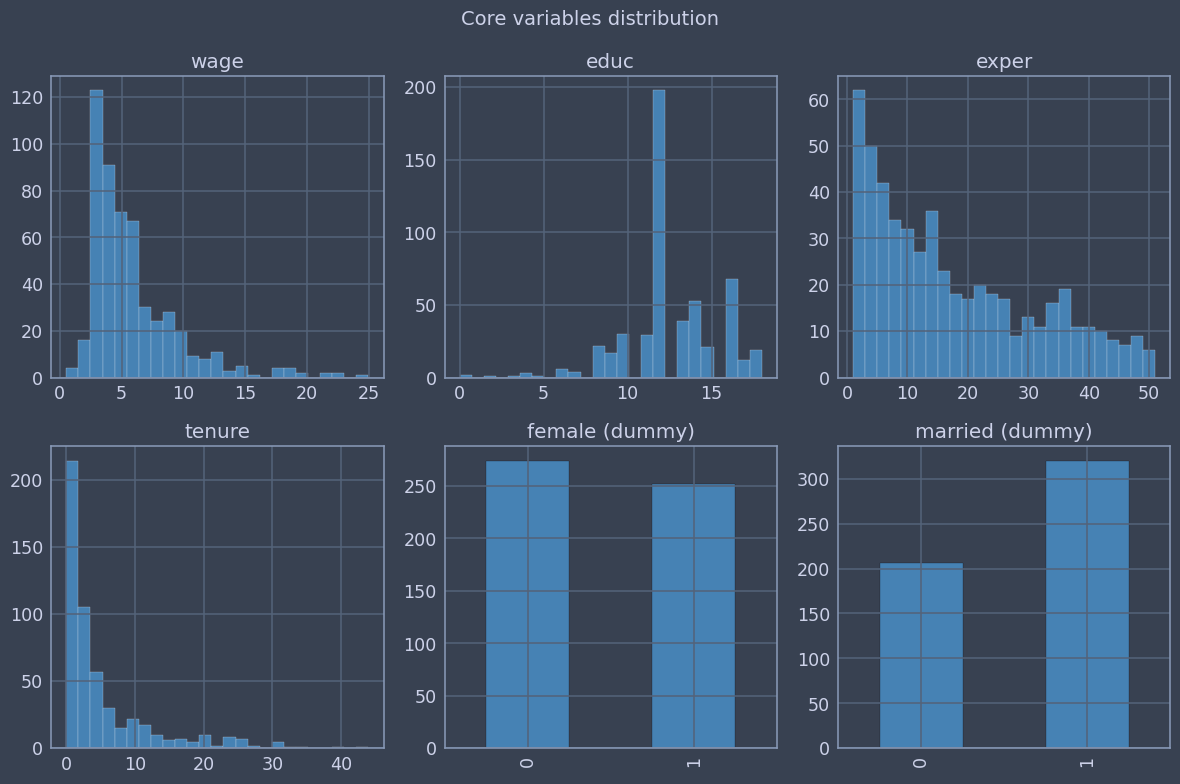

In [128]:
# 分布可视化：连续变量直方图，虚拟变量条形图
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, v in enumerate(vars_core):
    ax = axes[i]
    if data[v].nunique() <= 3:  # 视为虚拟变量
        data[v].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'{v} (dummy)')
    else:
        data[v].hist(ax=ax, bins=25, color='steelblue', edgecolor='white')
        ax.set_title(v)
    ax.set_xlabel('')
plt.suptitle('Core variables distribution', fontsize=14)
plt.tight_layout()
plt.show()

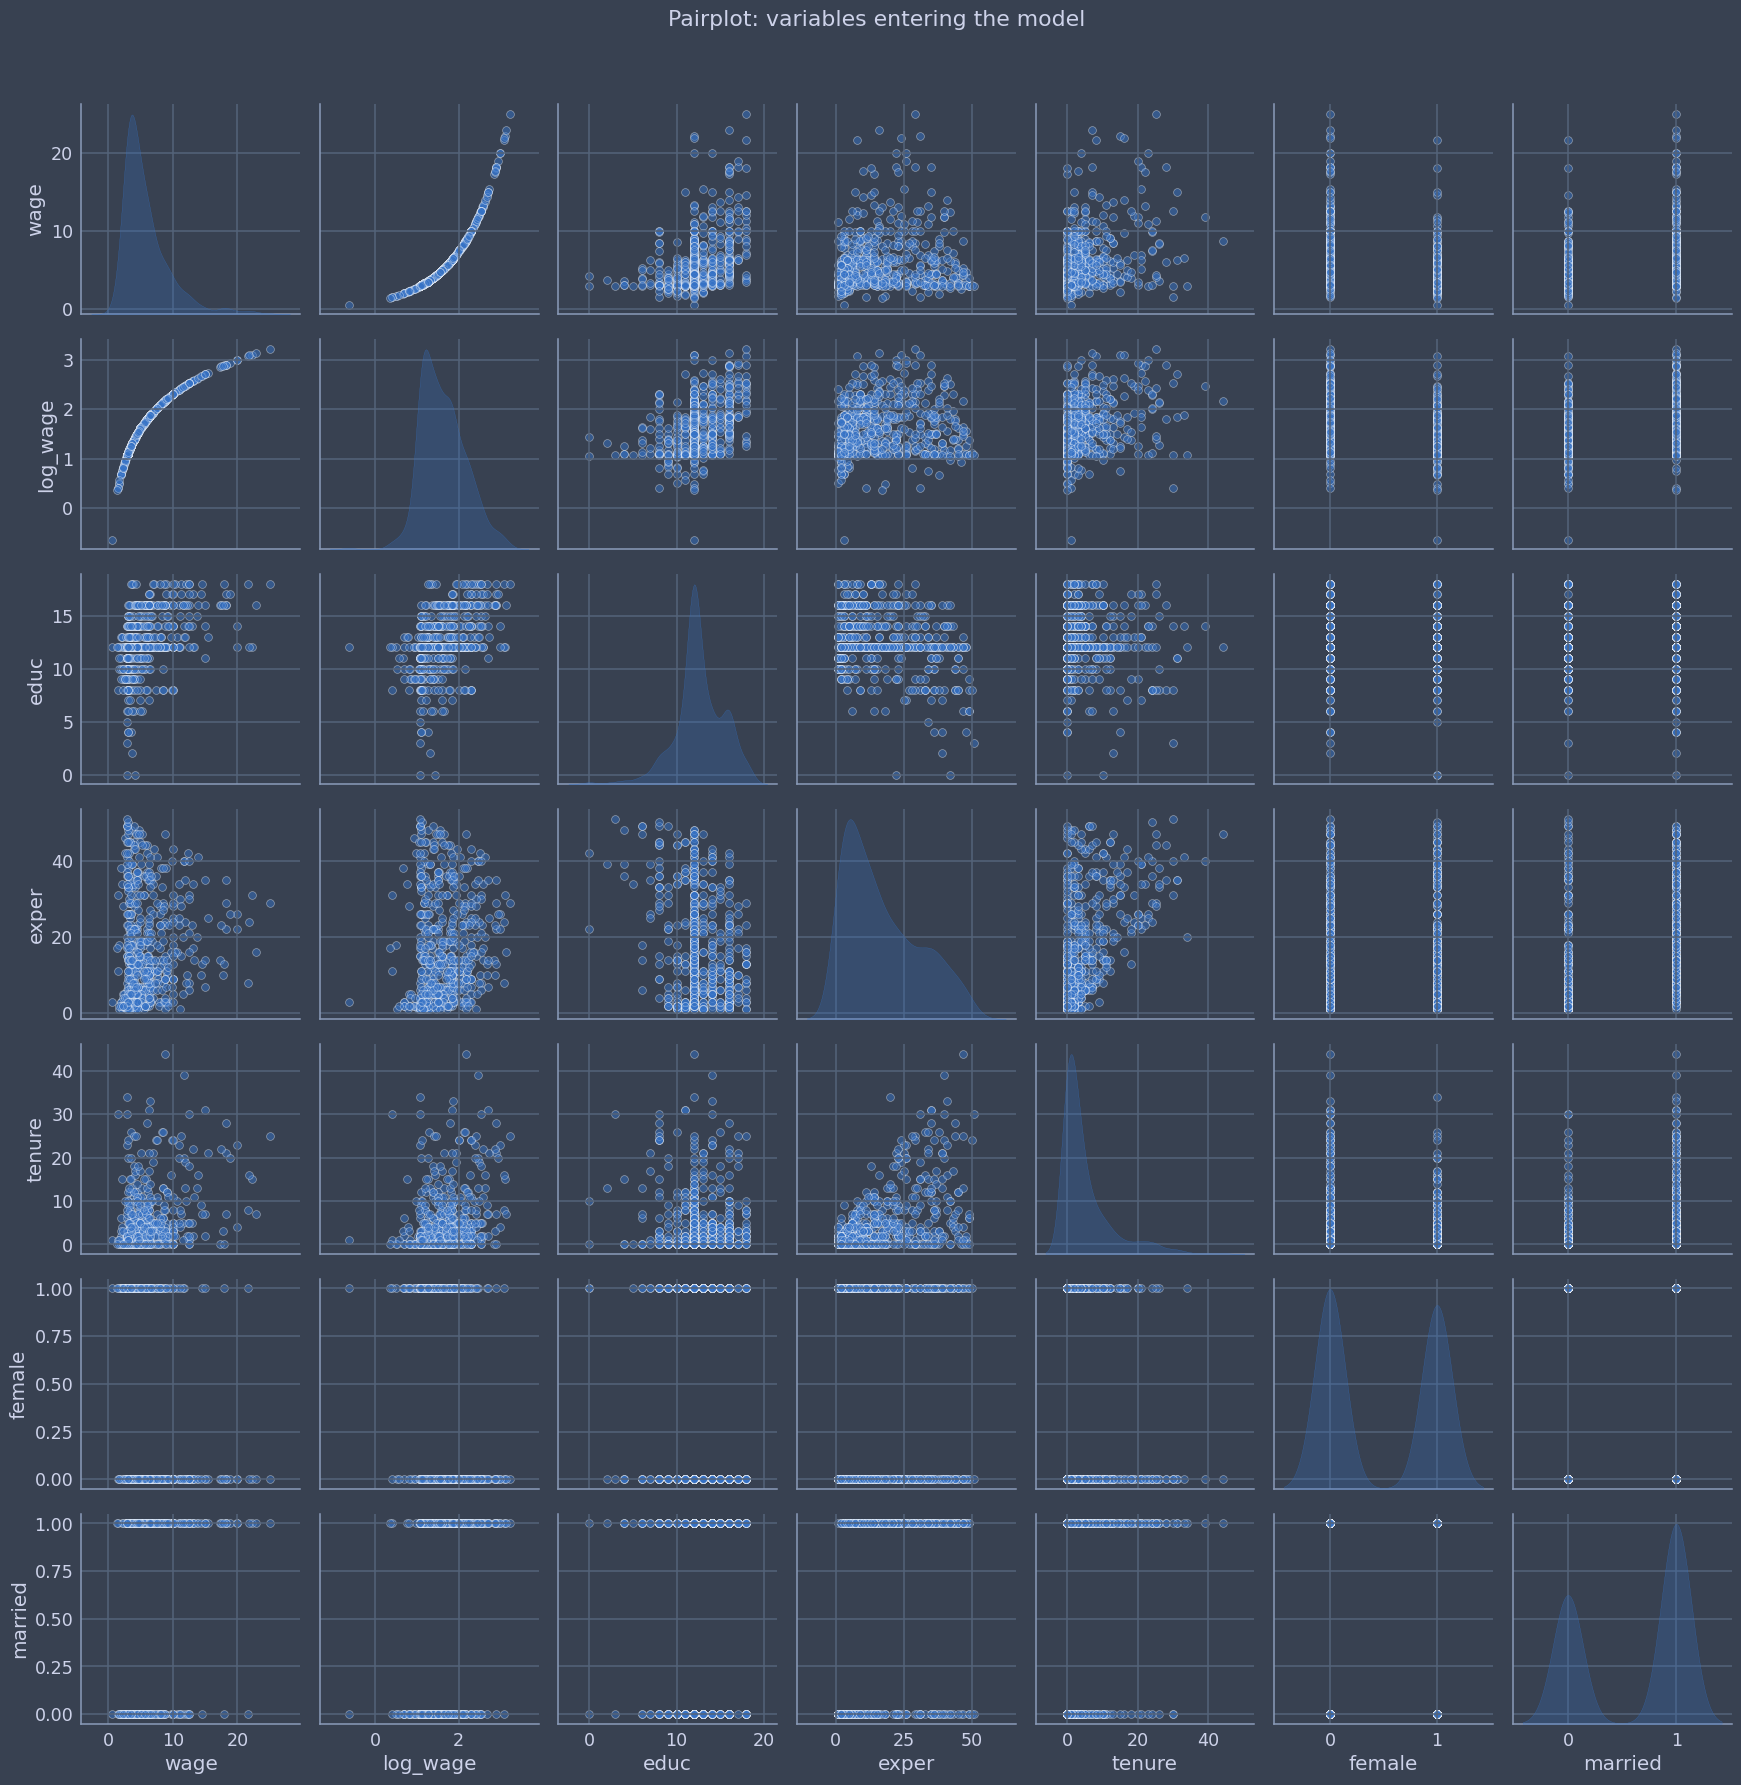

In [129]:
# 进入模型变量的相关性网格图：观察 wage, log_wage, educ, exper, tenure, female, married 两两关系
data['log_wage'] = np.log(data['wage'])
vars_pairplot = ['wage', 'log_wage', 'educ', 'exper', 'tenure', 'female', 'married']
sns.pairplot(data[vars_pairplot], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot: variables entering the model', y=1.02)
plt.tight_layout()
plt.show()

## 3. 函数形式对比：Level-Level vs Semi-Log

In [130]:
# Level-Level：wage 对解释变量的线性回归（系数表示“绝对”美元变化）
formula_ll = 'wage ~ educ + exper + tenure + C(female) + C(married)'
res_ll = smf.ols(formula_ll, data=data).fit()
print('=== Level-Level 模型 ===')
print(res_ll.summary())

=== Level-Level 模型 ===
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     60.61
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.02e-49
Time:                        16:55:24   Log-Likelihood:                -1312.3
No. Observations:                 526   AIC:                             2637.
Df Residuals:                     520   BIC:                             2662.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          

In [131]:
# Semi-Log：log(wage) 对解释变量回归（系数可解释为半弹性：x 增加 1 单位，wage 约变化 β*100%）
# 劳动力经济学中薪资常呈对数正态分布，Semi-Log 更符合惯例且系数易解释
data['log_wage'] = np.log(data['wage'])
formula_log = 'log_wage ~ educ + exper + tenure + C(female) + C(married)'
res_log = smf.ols(formula_log, data=data).fit()
print('=== Semi-Log 模型 ===')
print(res_log.summary())

=== Semi-Log 模型 ===
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     70.38
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           3.57e-56
Time:                        16:55:24   Log-Likelihood:                -277.50
No. Observations:                 526   AIC:                             567.0
Df Residuals:                     520   BIC:                             592.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.

In [132]:
# 诊断对比：残差正态性（Jarque-Bera）与条件数（Condition Number）
# 正态性：JB 不拒绝时 OLS 推断更可靠；条件数过大提示多重共线性风险
def jb_and_cn(res, name):
    jb_stat, jb_pval, sk, kurt = jarque_bera(res.resid)
    # 条件数：设计矩阵奇异值的最大/最小比，>30 常认为存在较强共线性
    X = res.model.exog
    cond = np.linalg.cond(X)
    print(f'【{name}】')
    print(f'  Jarque-Bera: 统计量={jb_stat:.4f}, p值={jb_pval:.4f} → {"残差近似正态" if jb_pval > 0.05 else "残差显著非正态"}')
    print(f'  Condition Number: {cond:.2f} → {"需关注多重共线性" if cond > 30 else "共线性可接受"}')
    return jb_pval, cond

jb_ll, cn_ll = jb_and_cn(res_ll, 'Level-Level')
print()
jb_log, cn_log = jb_and_cn(res_log, 'Semi-Log')

【Level-Level】
  Jarque-Bera: 统计量=730.1509, p值=0.0000 → 残差显著非正态
  Condition Number: 140.69 → 需关注多重共线性

【Semi-Log】
  Jarque-Bera: 统计量=21.1521, p值=0.0000 → 残差显著非正态
  Condition Number: 140.69 → 需关注多重共线性


In [133]:
# 小结：根据劳动力经济学惯例（薪资对数正态），重点评估对数模型。
# 若 Semi-Log 的 JB p 值更大且/或条件数更小，则更支持采用 Semi-Log 作为基准。
print('结论：后续以 Semi-Log 为基准，便于解释教育/经验/性别/婚姻对薪资的百分比影响。')

结论：后续以 Semi-Log 为基准，便于解释教育/经验/性别/婚姻对薪资的百分比影响。


## 3.5 深度诊断（Diagnostics）：VIF 与 RESET

In [134]:
# 为当前 Semi-Log 模型（res_log）的所有自变量计算 VIF，精确量化 exper 与 tenure 的共线性程度
# VIF > 10 通常认为存在严重共线性；Cond. No. 141 提示需用 VIF 进一步确认
X = res_log.model.exog
names = res_log.model.exog_names
vif_list = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_df = pd.DataFrame({'variable': names, 'VIF': vif_list}).round(4)
print('VIF（方差膨胀因子）— 当前 Semi-Log 模型')
print(vif_df)
print('\n若 exper 与 tenure 的 VIF 明显偏高，说明二者相关性较强，可考虑用 other_exper = exper - tenure 拆分。')

VIF（方差膨胀因子）— 当前 Semi-Log 模型
          variable      VIF
0        Intercept  31.6083
1   C(female)[T.1]   1.0715
2  C(married)[T.1]   1.1778
3             educ   1.1505
4            exper   1.6084
5           tenure   1.4069

若 exper 与 tenure 的 VIF 明显偏高，说明二者相关性较强，可考虑用 other_exper = exper - tenure 拆分。


In [135]:
# Ramsey RESET 检验：验证当前模型是否遗漏变量的高次项（尤其是经验的平方项）
reset_res = linear_reset(res_log, power=3, test_type='fitted', use_f=True)
print('Ramsey RESET 检验（基于 Semi-Log 模型，加入拟合值 2、3 次幂）')
print(reset_res)
print('\n若 p < 0.05 拒绝 H0，提示可能遗漏非线性项（如 I(exper**2)）。')

Ramsey RESET 检验（基于 Semi-Log 模型，加入拟合值 2、3 次幂）
<F test: F=7.692271139856032, p=0.0005104316224996419, df_denom=518, df_num=2>

若 p < 0.05 拒绝 H0，提示可能遗漏非线性项（如 I(exper**2)）。


## 4. 稳健推断与虚拟变量（HC3 + 半弹性解释）

In [136]:
# 在对数模型基础上使用 HC3 稳健标准误，放松同方差假设，使 t/F 推断更稳健
res_log_robust = res_log.get_robustcov_results(cov_type='HC3')
print('=== Semi-Log 模型（HC3 稳健标准误）===')
print(res_log_robust.summary())

=== Semi-Log 模型（HC3 稳健标准误）===
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     62.16
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           9.13e-51
Time:                        16:55:25   Log-Likelihood:                -277.50
No. Observations:                 526   AIC:                             567.0
Df Residuals:                     520   BIC:                             592.6
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept   

In [137]:
# 虚拟变量系数的“半弹性”含义（在 log(wage) 模型中）：
# female：C(female)[T.1] 表示 female=1（女性）相对参照组（男性）的 log(wage) 差异；
#         近似地，女性相比男性薪资平均低 (1 - exp(β))×100%。
# married：C(married)[T.1] 表示已婚相对未婚的 log(wage) 差异；
#           近似地，已婚者相比未婚者薪资平均高 (exp(β)-1)×100%。
# params 在 HC3 稳健结果中可能为 ndarray，用 model.exog_names 保证能按名称取值
params = res_log_robust.params
names = getattr(params, 'index', None)
if names is None:
    names = res_log_robust.model.exog_names
    coef = pd.Series(params, index=names)
else:
    coef = params
key_f = [x for x in names if 'female' in x]
key_m = [x for x in names if 'married' in x]
if key_f and key_m:
    key_f, key_m = key_f[0], key_m[0]
    b_f = coef[key_f]
    b_m = coef[key_m]
    pct_f = (1 - np.exp(b_f)) * 100
    pct_m = (np.exp(b_m) - 1) * 100
    print(f'女性相对男性：系数 ≈ {b_f:.4f} → 薪资平均约低 {pct_f:.2f}%')
    print(f'已婚相对未婚：系数 ≈ {b_m:.4f} → 薪资平均约高 {pct_m:.2f}%')

女性相对男性：系数 ≈ -0.2855 → 薪资平均约低 24.84%
已婚相对未婚：系数 ≈ 0.1257 → 薪资平均约高 13.40%


## 4.5 交互项探索：female × educ

In [140]:
# 加入 female 与 educ 的交互项，检验教育对女性薪资的提升作用是否与男性一致
# 公式 educ*C(female) 展开为 educ + C(female) + educ:C(female)；交互项系数显著为负→女性教育回报更低，显著为正→更高，不显著→相近
formula_interact = 'log_wage ~ exper + tenure + C(married) + educ*C(female)'
res_female_educ = smf.ols(formula_interact, data=data).fit(cov_type='HC3')
print('=== Semi-Log + female × educ 交互项（HC3）===')
print(res_female_educ.summary())

=== Semi-Log + female × educ 交互项（HC3）===
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     53.37
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           3.46e-51
Time:                        17:55:20   Log-Likelihood:                -277.37
No. Observations:                 526   AIC:                             568.7
Df Residuals:                     519   BIC:                             598.6
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [141]:
# 解读：男性教育回报 = educ 系数；女性教育回报 = educ 系数 + educ:C(female)[T.1] 系数
p = res_female_educ.params
n = getattr(p, 'index', None)
if n is None:
    n = res_female_educ.model.exog_names
    p = pd.Series(res_female_educ.params, index=n)
b_educ = p['educ']
key_interact = [k for k in n if 'educ' in k and 'female' in k]
if key_interact:
    b_interact = p[key_interact[0]]
    print(f'男性：多 1 年教育 → log(wage) 约 +{b_educ:.4f}（约 {100*b_educ:.2f}%）')
    print(f'女性：多 1 年教育 → log(wage) 约 +{b_educ + b_interact:.4f}（约 {100*(b_educ + b_interact):.2f}%），交互项 = {b_interact:.4f}')
    print('交互项显著为负 → 教育对女性薪资提升弱于男性；显著为正 → 强于男性；不显著 → 两者相近。')

男性：多 1 年教育 → log(wage) 约 +0.0866（约 8.66%）
女性：多 1 年教育 → log(wage) 约 +0.0797（约 7.97%），交互项 = -0.0069
交互项显著为负 → 教育对女性薪资提升弱于男性；显著为正 → 强于男性；不显著 → 两者相近。


## 5. 模型设定偏误诊断：Ramsey RESET 检验

In [142]:
# RESET 检验：在原有回归中加入拟合值的幂（如 2 次、3 次），检验是否遗漏非线性/乘积项
# 若拒绝 H0，提示可能存在设定偏误，例如遗漏了经验的非线性回报（如 exper^2）
reset_res = linear_reset(res_log, power=3, test_type='fitted', use_f=True)
print('Ramsey RESET 检验（基于 Semi-Log 模型，加入拟合值 2、3 次幂）')
print(reset_res)

Ramsey RESET 检验（基于 Semi-Log 模型，加入拟合值 2、3 次幂）
<F test: F=7.692271139856032, p=0.0005104316224996419, df_denom=518, df_num=2>


In [143]:
# 若 RESET 显著（p < 0.05）：提示可能遗漏了非线性项。
# 劳动力经济学中常见“经验的倒 U 型回报”：薪资随工龄先增后减，故加入 exper^2 是合理扩展。

## 6. 非线性特征：经验的平方项（倒 U 型）

In [144]:
# 对 exper 进行中心化（Mean-centering）后再平方，降低 exper 与 exper^2 的共线性、稳定系数估计
data['exper_c'] = data['exper'] - data['exper'].mean()
print('exper_c = exper - mean(exper), mean(exper) =', round(data['exper'].mean(), 4))

exper_c = exper - mean(exper), mean(exper) = 17.0171


In [145]:
# 在公式中用 exper_c 与 I(exper_c**2) 加入中心化后的经验及平方项，验证“先增后减”的生命周期理论
# 预期：exper_c 系数为正，exper_c^2 系数为负；拐点（原尺度）exper* = mean(exper) - β_exper_c/(2*β_exper_c2)
formula_log2 = 'log_wage ~ educ + exper_c + I(exper_c**2) + tenure + C(female) + C(married)'
res_log2 = smf.ols(formula_log2, data=data).fit()
print('=== Semi-Log + exper_c^2 (mean-centered) ===')
print(res_log2.summary())

=== Semi-Log + exper_c^2 (mean-centered) ===
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     66.91
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.76e-61
Time:                        17:55:29   Log-Likelihood:                -262.76
No. Observations:                 526   AIC:                             539.5
Df Residuals:                     519   BIC:                             569.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [146]:
# 拐点计算（中心化后）：∂log(wage)/∂exper_c = β_exper_c + 2*β_exper_c2*exper_c = 0 => exper_c* = -β_exper_c/(2*β_exper_c2)
# 换算回原尺度：exper* = mean(exper) + exper_c* = mean(exper) - β_exper_c/(2*β_exper_c2)
b_exper_c = res_log2.params['exper_c']
key_exper2 = [k for k in res_log2.params.index if 'exper_c' in k and '**' in k][0]
b_exper2 = res_log2.params[key_exper2]
if b_exper2 < 0:
    exper_c_star = -b_exper_c / (2 * b_exper2)
    exper_star = data['exper'].mean() + exper_c_star
    print(f'经验回报拐点（年）: exper* = {exper_star:.1f} → 工龄超过此值后边际回报递减')

经验回报拐点（年）: exper* = 25.0 → 工龄超过此值后边际回报递减


## 6.5 变量工程与完整明瑟方程（Mincer v2）

In [147]:
# 将总经验拆分为“入职前经验”与“本公司资历”，降低 exper 与 tenure 的共线性
data['other_exper'] = data['exper'] - data['tenure']
print('other_exper = exper - tenure（入职前经验）')
print(data[['exper', 'tenure', 'other_exper']].describe().round(4))

other_exper = exper - tenure（入职前经验）
          exper    tenure  other_exper
count  526.0000  526.0000     526.0000
mean    17.0171    5.1046      11.9125
std     13.5722    7.2245      11.7679
min      1.0000    0.0000     -14.0000
25%      5.0000    0.0000       3.0000
50%     13.5000    2.0000       8.0000
75%     26.0000    7.0000      18.0000
max     51.0000   44.0000      49.0000


In [148]:
# 完整版明瑟方程：educ + other_exper + tenure + I(exper_c**2)（中心化后平方），HC3 稳健推断
formula_mincer_v2 = 'log_wage ~ educ + other_exper + tenure + I(exper_c**2) + C(female) + C(married)'
model_mincer_v2 = smf.ols(formula_mincer_v2, data=data).fit(cov_type='HC3')
print('=== Mincer v2（other_exper + exper^2, HC3）===')
print(model_mincer_v2.summary())

=== Mincer v2（other_exper + exper^2, HC3）===
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     63.09
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.14e-58
Time:                        17:55:34   Log-Likelihood:                -262.76
No. Observations:                 526   AIC:                             539.5
Df Residuals:                     519   BIC:                             569.4
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [149]:
# 结果分析注释：
# 1) I(exper_c**2) 系数是否为负？若为负，则验证薪资随工龄“先增后减”的倒 U 型规律。
# 2) 使用 other_exper 后，原本不显著的 exper（在 res_log 中）是否变得显著？other_exper 与 tenure 分离后共线性降低。
# 3) 对比 res_log2 与 model_mincer_v2 的 AIC：AIC 更低表示拟合质量更好（在惩罚复杂度后）。
params_v2 = model_mincer_v2.params
if hasattr(params_v2, 'index'):
    names_v2 = params_v2.index
    coef_v2 = params_v2
else:
    names_v2 = model_mincer_v2.model.exog_names
    coef_v2 = pd.Series(params_v2, index=names_v2)
key_exper2_v2 = [k for k in names_v2 if 'exper_c' in k and '**' in k]
if key_exper2_v2:
    b_exper2_v2 = coef_v2[key_exper2_v2[0]]
    print(f'I(exper_c**2) 系数 = {b_exper2_v2:.6f} → {"为负，符合倒 U 型" if b_exper2_v2 < 0 else "为正或接近 0"}')
print(f'\nAIC 对比: res_log2 = {res_log2.aic:.2f}, model_mincer_v2 = {model_mincer_v2.aic:.2f}')
print('AIC 更低者拟合更优（在惩罚参数个数后）。')

I(exper_c**2) 系数 = -0.000601 → 为负，符合倒 U 型

AIC 对比: res_log2 = 539.51, model_mincer_v2 = 539.51
AIC 更低者拟合更优（在惩罚参数个数后）。


## 7. 最终模型对比与总结

In [150]:
# 对比 AIC 与 Adjusted R-squared（AIC 越小越好，Adj R² 越大越好）
models = {
    'Level-Level': res_ll,
    'Semi-Log': res_log,
    'Semi-Log + exper^2': res_log2,
    'Mincer v2 (other_exper+exper^2, HC3)': model_mincer_v2
}
cmp = pd.DataFrame({
    'AIC': [m.aic for m in models.values()],
    'Adj R²': [m.rsquared_adj for m in models.values()]
}, index=models.keys())
print('模型比较')
print(cmp.round(4))
print('\nMincer v2 在降低共线性（other_exper）并加入 exper^2 后，若 AIC 更低则拟合更优。')

模型比较
                                            AIC  Adj R²
Level-Level                           2636.6003  0.3621
Semi-Log                               567.0096  0.3979
Semi-Log + exper^2                     539.5109  0.4296
Mincer v2 (other_exper+exper^2, HC3)   539.5109  0.4296

Mincer v2 在降低共线性（other_exper）并加入 exper^2 后，若 AIC 更低则拟合更优。


In [151]:
# 最终模型 Summary（带 exper^2 的 Semi-Log）
print('========== 最终模型 Summary ==========')
print(res_log2.summary())

========== 最终模型 Summary ==========
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     66.91
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.76e-61
Time:                        17:55:41   Log-Likelihood:                -262.76
No. Observations:                 526   AIC:                             539.5
Df Residuals:                     519   BIC:                             569.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Interce

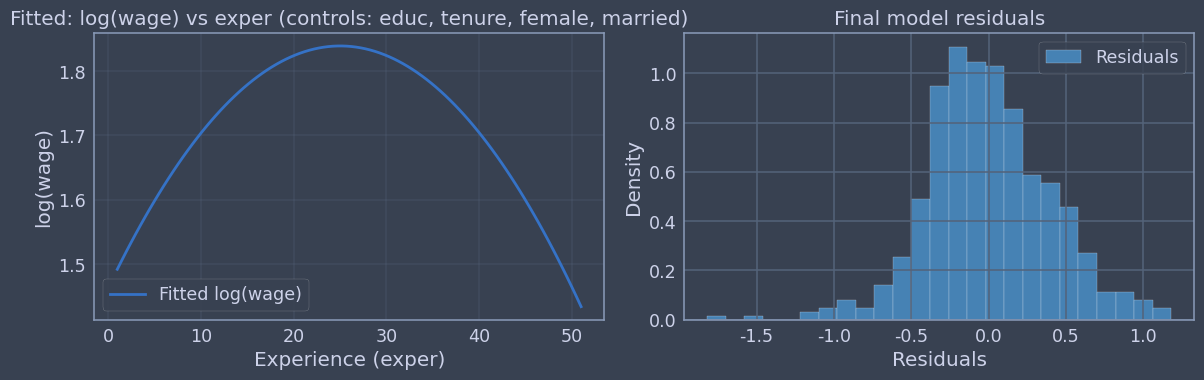

In [152]:
# 拟合曲线图：控制其他变量时 log(wage) 与 exper 的关系（倒 U 型）；模型使用 exper_c，预测时 exper_c = exper_grid - mean(exper)
med_educ = data['educ'].median()
med_tenure = data['tenure'].median()
exper_grid = np.linspace(data['exper'].min(), data['exper'].max(), 100)
exper_c_grid = exper_grid - data['exper'].mean()
X_pred = pd.DataFrame({
    'educ': med_educ, 'exper_c': exper_c_grid, 'tenure': med_tenure,
    'female': 0, 'married': 1
})
log_wage_pred = res_log2.predict(X_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(exper_grid, log_wage_pred, 'b-', lw=2, label='Fitted log(wage)')
axes[0].set_xlabel('Experience (exper)')
axes[0].set_ylabel('log(wage)')
axes[0].set_title('Fitted: log(wage) vs exper (controls: educ, tenure, female, married)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 残差分布图（最终模型）
axes[1].hist(res_log2.resid, bins=25, color='steelblue', edgecolor='white', density=True, label='Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Density')
axes[1].set_title('Final model residuals')
axes[1].legend()
plt.tight_layout()
plt.show()

In [153]:
# 多重共线性提示：若前面某模型条件数 > 30，可考虑中心化、剔除高度相关变量或主成分等。
cond_final = np.linalg.cond(res_log2.model.exog)
print(f'最终模型条件数: {cond_final:.2f}')
if cond_final > 30:
    print('提示：条件数较大，存在多重共线性风险，可考虑对 exper/tenure 中心化或检查变量相关性。')

最终模型条件数: 1604.53
提示：条件数较大，存在多重共线性风险，可考虑对 exper/tenure 中心化或检查变量相关性。
